# Accuracy test

In [68]:
import pandas as pd
import json
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import spacy
import re
import pycountry
from functions import *
from LLM_functions import *

#Package for accuracy 
from sklearn.metrics.pairwise import cosine_similarity

#For plotting
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import cartopy.io.shapereader as shpreader

In [124]:
fig_path = '/home/lhasbini/como_school/figure/'
file_path_save = '/scratchx/lhasbini/como_school/'
file_path = '/scratchx/lhasbini/como_school/filtered_report_types_nat_hazards_summary-header.json'

# Open and read the JSON file
with open(file_path, 'r') as json_file:
    filtered_reports = json.load(json_file)

unique_hazards = ['Drought', 'Flood', 'Storm', 'Tornado', 'Storm surge', 'Heatwave', 'Coldwave', 'Mass movement', 'Cyclone', 'Tidal Wave', 'Wildfire'] 
#unique_countries_ISO = [country.alpha_3 for country in pycountry.countries]

In [3]:
dict_output = [
    {
        "Hazard": "Flood",
        "Name": "NULL",
        "Country": "Kenya",
        "Locations": "Nairobi",
        "Start_Date": "March-April-May",
        "End_Date": "NULL",
        "Hazard_Sentences": "Communities in Kenya are once again facing heavy rains and devastating floods. The floods have also hit the capital in residential informal settlements areas of Nairobi as rivers overflowed."
    },
    {
        "Hazard": "Landslide",
        "Name": "NULL",
        "Country": "Kenya",
        "Locations": "NULL",
        "Start_Date": "NULL",
        "End_Date": "NULL",
        "Hazard_Sentences": "There were also cases of landslides and mudslides in central Kenya affecting both families with even young children."
    },
    {
        "Hazard": "Drought",
        "Name": "NULL",
        "Country": "Kenya",
        "Locations": "NULL",
        "Start_Date": "four decades",
        "End_Date": "NULL",
        "Hazard_Sentences": "The floods of 2023 floods and these 2024 floods are exacerbating the humanitarian crisis as part of the country have just emerged from the worst drought in four decades, which has left millions of people hungry."
    } 
]

In [4]:
dict_test_labelled = [
    {
        "Hazard": "Flood",
        "Name": "NULL",
        "Country": "Kenya",
        "Locations": "Nairobi",
        "Start_Date": "March-April-May",
        "End_Date": "NULL",
        "Hazard_Sentences": "Communities in Kenya are once again facing heavy rains and devastating floods. The floods have also hit the capital in residential informal settlements areas of Nairobi as rivers overflowed."
    },
    {
        "Hazard": "Cyclone",
        "Name": "NULL",
        "Country": "Kenya",
        "Locations": "Central Kenya",
        "Start_Date": "NULL",
        "End_Date": "NULL",
        "Hazard_Sentences": "There were also cases of landslides and mudslides in central Kenya affecting both families with even young children."
    },
    {
        "Hazard": "Drought",
        "Name": "NULL",
        "Country": "Cameroon",
        "Locations": "NULL",
        "Start_Date": "four decades",
        "End_Date": "NULL",
        "Hazard_Sentences": "The floods of 2023 floods and these 2024 floods are exacerbating the humanitarian crisis as part of the country have just emerged from the worst drought in four decades, which has left millions of people hungry."
    } 
]

In [5]:
def extract_outer_json(text):
    start_index = text.find('{')
    end_index = text.rfind('}')

    if start_index == -1 or end_index == -1 or start_index >= end_index:
        return None  # Return None for empty JSON or invalid format

    extracted_json = text[start_index:end_index + 1]
    return extracted_json

In [6]:
df_output = pd.DataFrame(dict_output)
df_output['appealCode'] = 'MDRDZ011'

df_test_labelled = pd.DataFrame(dict_test_labelled)
df_test_labelled['appealCode'] = 'MDRDZ011'

In [7]:
#Convert countries to ISO code 3 
df_output['Country'] = [country_name_to_iso3(cntr) for cntr in df_output['Country']]
df_test_labelled['Country'] = [country_name_to_iso3(cntr) for cntr in df_test_labelled['Country']]

In [8]:
unique_dict = {
    'Hazard' : unique_hazards, 
    'Country' : unique_countries_ISO
}

In [9]:
columns_accuracy = ['Hazard', 'Country', 'Locations', 'Start_Date', 'End_Date']#['Hazard_Type', 'Hazard_Count', 'Country']
precision = calculate_precision(df_output, df_test_labelled, columns_accuracy)

In [10]:
precision

,Hazard,Country,Locations,Start_Date,End_Date
0,0.816497,0.707107,0.5,1.0,NaN


# Prepare test examples 

In [99]:
filtered_reports[0]['appealCode']

'MDRDZ011'

In [100]:
dict_0=[
    {
      "Hazard": "Flood",
      "Country" : "Algeria", 
      "Locations": ["southern and western Algeria", "Bchar, Elbayadh, Beni Abbes, Tamanrasset, Tiaret, Tindouf, and Naama"],
      "Start_Date": "September 5, 2024",
      "End_Date": "September 8, 2024",
      "Name": "" 
    }
]

In [103]:
df_0 = pd.DataFrame(dict_0)
df_0['appealCode'] = filtered_reports[0]['appealCode']
df_0['Country'] = [country_name_to_iso3(cntr) for cntr in df_0['Country']]

In [104]:
filtered_reports[1]['appealCode']
#filtered_reports[1]['header']

'MDRPK026'

In [107]:
dict_1 = [
    {
        "Hazard": "Flood",
        "Name": "NULL",
        "Country": "Pakistan ",
        "Locations": ["Balochistan ", "Sindh ", "Punjab", "Khyber Pakhtunkhwa KP", "Azad Jammu", "Khyber Pakhtunkhwa KP", 
                     "Jacobabad, Naushahro Feroz, Ghotki, Sukkur, Sanghar, Dadu, Shaheed Benazirabad, and Kashmor", 
                     "Taluka Tando Adam"],
        "Start_Date": "July 2024",
        "End_Date": "NULL",
        #"Hazard_Sentences": "Communities in Kenya are once again facing heavy rains and devastating floods. The floods have also hit the capital in residential informal settlements areas of Nairobi as rivers overflowed."
    },
    {
        "Hazard": "Mass movement",
        "Name": "NULL",
        "Country": "Pakistan",
        "Locations": ["KP, Azad Jammu and Kashmir AJK, and GilgitBaltistan GB"],
        "Start_Date": "NULL",
        "End_Date": "NULL",
        #"Hazard_Sentences": "There were also cases of landslides and mudslides in central Kenya affecting both families with even young children."
    },
    {
        "Hazard": "Heat Wave",
        "Name": "NULL",
        "Country": "Pakistan",
        "Locations": "NULL",
        "Start_Date": "26 August 2024",
        "End_Date": "1 September 2024",
        #"Hazard_Sentences": "There were also cases of landslides and mudslides in central Kenya affecting both families with even young children."
    }
]

In [108]:
df_1 = pd.DataFrame(dict_1)
df_1['appealCode'] = filtered_reports[1]['appealCode']
df_1['Country'] = [country_name_to_iso3(cntr) for cntr in df_1['Country']]

In [40]:
filtered_reports[2]['appealCode']
#filtered_reports[2]['header']

'MDRCM039'

In [109]:
dict_2 = [
    {
        "Hazard": "Flood",
        "Name": "NULL",
        "Country": "Cameroon ",
        "Locations": ["Cameroons Far North region", "Logone et Chari and Mayo Danay", "Yagoua", "Blangoua, Mackary, and Zina", 
                      "Chari division", "Maga, Yagoua", "Logone division", "Ndoukoula district"],
        "Start_Date": "second half of July 2024",
        "End_Date": "August 28, 2024",
        #"Hazard_Sentences": "Communities in Kenya are once again facing heavy rains and devastating floods. The floods have also hit the capital in residential informal settlements areas of Nairobi as rivers overflowed."
    },
    {
        "Hazard": "Drought",
        "Name": "NULL",
        "Country": "Cameroon",
        "Locations": "NULL",
        "Start_Date": "2024",
        "End_Date": "NULL",
        #"Hazard_Sentences": "There were also cases of landslides and mudslides in central Kenya affecting both families with even young children."
    }
]

df_2 = pd.DataFrame(dict_2)
df_2['appealCode'] = filtered_reports[2]['appealCode']
df_2['Country'] = [country_name_to_iso3(cntr) for cntr in df_2['Country']]

In [42]:
filtered_reports[3]['appealCode']
#filtered_reports[3]['header']

'MDRBJ019'

In [112]:
dict_3 = [
    {
        "Hazard": "Flood",
        "Name": "NULL",
        "Country": "Benin ",
        "Locations": ["Mono, Couffo, Zou and Oum in the South of Benin", "Couffo department, Adoukandji, Ahomadegbe, Gnizounme, Tchito, Tohou and Zalli", 
                      "Ahouada, Hazin, Yamontou, Ahomadegbe, Gnizounme, Hangbannou, Tandji, Aboti, Zounhome, Hehokpa, Sawanou, Tohou Centre and Adjassagon"
                     ],
        "Start_Date": "26 June 2024",
        "End_Date": "NULL",
        #"Hazard_Sentences": "Communities in Kenya are once again facing heavy rains and devastating floods. The floods have also hit the capital in residential informal settlements areas of Nairobi as rivers overflowed."
    }
]

df_3 = pd.DataFrame(dict_3)
df_3['appealCode'] = filtered_reports[3]['appealCode']
df_3['Country'] = [country_name_to_iso3(cntr) for cntr in df_3['Country']]

In [41]:
print(filtered_reports[4]['appealCode'])
#print(filtered_reports[4]['header'])

MDRSD034


In [113]:
dict_4 = [
    {
        "Hazard": "Flood",
        "Name": "NULL",
        "Country": "Sudan",
        "Locations": ["Red Sea, River Nile, and Northern State" 
                     ],
        "Start_Date": "1 June 2024",
        "End_Date": "12 August 2024",
        #"Hazard_Sentences": "Communities in Kenya are once again facing heavy rains and devastating floods. The floods have also hit the capital in residential informal settlements areas of Nairobi as rivers overflowed."
    }
]
df_4 = pd.DataFrame(dict_4)
df_4['appealCode'] = filtered_reports[4]['appealCode']
df_4['Country'] = [country_name_to_iso3(cntr) for cntr in df_4['Country']]

In [43]:
print(filtered_reports[5]['appealCode'])
#print(filtered_reports[5]['header'])

MDRNG041


In [114]:
dict_5 = [
    {
        "Hazard": "Flood",
        "Name": "NULL",
        "Country": "Nigeria",
        "Locations": ["Kano", "Maiduguri", "Bauchi state", "Bauchi, Kebbi, Sokoto, Zamfara"
                     ],
        "Start_Date": "8 August 2024",
        "End_Date": "13 August 2024",
        #"Hazard_Sentences": "Communities in Kenya are once again facing heavy rains and devastating floods. The floods have also hit the capital in residential informal settlements areas of Nairobi as rivers overflowed."
    }, 
    {
        "Hazard": "Flood",
        "Name": "NULL",
        "Country": "Nigeria",
        "Locations": ["Sokoto State", "Dantudu, Balakozo, Gidan Tudu, and Tsitse", "Zamfara State", "Ruwan Gora, Morai, Makera, and Talata Mafara town"],
        "Start_Date": "17 July 2024",
        "End_Date": "NULL",
        #"Hazard_Sentences": "Communities in Kenya are once again facing heavy rains and devastating floods. The floods have also hit the capital in residential informal settlements areas of Nairobi as rivers overflowed."
    }
]
df_5 = pd.DataFrame(dict_5)
df_5['appealCode'] = filtered_reports[5]['appealCode']
df_5['Country'] = [country_name_to_iso3(cntr) for cntr in df_5['Country']]

In [44]:
print(filtered_reports[6]['appealCode'])
#print(filtered_reports[6]['header'])

MDRRW022


In [116]:
dict_6 = [
    {
        "Hazard": "Flood",
        "Name": "NULL",
        "Country": "Rwanda",
        "Locations": ["western, northern and southern provinces", "14 districts"
                     ],
        "Start_Date": "1 May 2023",
        "End_Date": "June 2023",
        #"Hazard_Sentences": "Communities in Kenya are once again facing heavy rains and devastating floods. The floods have also hit the capital in residential informal settlements areas of Nairobi as rivers overflowed."
    }, 
    {
        "Hazard": "Mass Movement",
        "Name": "NULL",
        "Country": "Rwanda",
        "Locations": ["14 districts"
                     ],
        "Start_Date": "1 May 2023",
        "End_Date": "NULL",
        #"Hazard_Sentences": "Communities in Kenya are once again facing heavy rains and devastating floods. The floods have also hit the capital in residential informal settlements areas of Nairobi as rivers overflowed."
    }, 
]
df_6 = pd.DataFrame(dict_6)
df_6['appealCode'] = filtered_reports[6]['appealCode']
df_6['Country'] = [country_name_to_iso3(cntr) for cntr in df_6['Country']]

In [45]:
print(filtered_reports[7]['appealCode'])
#print(filtered_reports[7]['header'])

MDRZM022


In [117]:
dict_7 = [
    {
        "Hazard": "Drought",
        "Name": "NULL",
        "Country": "Zambia",
        "Locations": ["Lusaka, Luapula, and the Western, Southern, Central, and Northwestern Provinces", "Western, Southern, and NorthWestern."
                     ],
        "Start_Date": "29 February 2024",
        "End_Date": "NULL",
        #"Hazard_Sentences": "Communities in Kenya are once again facing heavy rains and devastating floods. The floods have also hit the capital in residential informal settlements areas of Nairobi as rivers overflowed."
    }
]
df_7 = pd.DataFrame(dict_7)
df_7['appealCode'] = filtered_reports[7]['appealCode']
df_7['Country'] = [country_name_to_iso3(cntr) for cntr in df_7['Country']]

In [38]:
print(filtered_reports[8]['appealCode'])
#print(filtered_reports[8]['header'])

MDRUG050


In [118]:
dict_8 = [
    {
        "Hazard": "Flood",
        "Name": "NULL",
        "Country": "Uganda",
        "Locations": ["Mbale, Kapchorwa, Bulambuli, Bukedea, Butaleja, Sironko, Bududa, and Namisindwa", 
                      "Manafwa, Lwakhakha, Sironko, Mpologoma, Awoja, Nbuyonga, and Namatala"],
        "Start_Date": "April 2024",
        "End_Date": "31st August 2024",
        #"Hazard_Sentences": "Communities in Kenya are once again facing heavy rains and devastating floods. The floods have also hit the capital in residential informal settlements areas of Nairobi as rivers overflowed."
    }, 
    {
        "Hazard": "Storm",
        "Name": "NULL",
        "Country": "Uganda",
        "Locations": ["Mbale, Kapchorwa, Bulambuli, Bukedea, Butaleja, Sironko, Bududa, and Namisindwa"],
        "Start_Date": "NULL",
        "End_Date": "NULL",
        #"Hazard_Sentences": "Communities in Kenya are once again facing heavy rains and devastating floods. The floods have also hit the capital in residential informal settlements areas of Nairobi as rivers overflowed."
    }, 
    {
        "Hazard": "Mass Movement",
        "Name": "NULL",
        "Country": "Uganda",
        "Locations": ["Mbale, Kapchorwa, Bulambuli, Bukedea, Butaleja, Sironko, Bududa, and Namisindwa"],
        "Start_Date": "NULL",
        "End_Date": "NULL",
        #"Hazard_Sentences": "Communities in Kenya are once again facing heavy rains and devastating floods. The floods have also hit the capital in residential informal settlements areas of Nairobi as rivers overflowed."
    }
]
df_8 = pd.DataFrame(dict_8)
df_8['appealCode'] = filtered_reports[8]['appealCode']
df_8['Country'] = [country_name_to_iso3(cntr) for cntr in df_8['Country']]

In [37]:
print(filtered_reports[9]['appealCode'])
#print(filtered_reports[9]['header'])

MDRMZ024


In [119]:
dict_9 = [
    {
        "Hazard": "Cyclone",
        "Name": "Filipo",
        "Country": "Mozambique",
        "Locations": [],
        "Start_Date": "March 2024",
        "End_Date": "NULL",
        #"Hazard_Sentences": "Communities in Kenya are once again facing heavy rains and devastating floods. The floods have also hit the capital in residential informal settlements areas of Nairobi as rivers overflowed."
    }, 
    {
        "Hazard": "Cyclone",
        "Name": "Freddy",
        "Country": "Mozambique",
        "Locations": [],
        "Start_Date": "2023",
        "End_Date": "NULL",
        #"Hazard_Sentences": "Communities in Kenya are once again facing heavy rains and devastating floods. The floods have also hit the capital in residential informal settlements areas of Nairobi as rivers overflowed."
    }, 
    {
        "Hazard": "Drought",
        "Name": "Freddy",
        "Country": "Mozambique",
        "Locations": ["central and northern zones"],
        "Start_Date": "May 2024",
        "End_Date": "June 2024",
        #"Hazard_Sentences": "Communities in Kenya are once again facing heavy rains and devastating floods. The floods have also hit the capital in residential informal settlements areas of Nairobi as rivers overflowed."
    }
]
df_9 = pd.DataFrame(dict_9)
df_9['appealCode'] = filtered_reports[9]['appealCode']
df_9['Country'] = [country_name_to_iso3(cntr) for cntr in df_9['Country']]

In [122]:
df_combined_examples = pd.concat([df_0, df_1, df_2, df_3, df_4, df_5, df_6, df_7, df_8, df_9], axis=0)

In [123]:
df_combined_examples.to_csv(file_path_save+'ex.csv', index=False)

,Hazard,Country,Locations,Start_Date,End_Date,Name,appealCode
0,Flood,DZA,"[southern and western Algeria, Bchar, Elbayadh...","September 5, 2024","September 8, 2024",,MDRDZ011
0,Flood,None,"[Balochistan , Sindh , Punjab, Khyber Pakhtunk...",July 2024,NULL,NULL,MDRPK026
1,Mass movement,PAK,"[KP, Azad Jammu and Kashmir AJK, and GilgitBal...",NULL,NULL,NULL,MDRPK026
2,Heat Wave,PAK,NULL,26 August 2024,1 September 2024,NULL,MDRPK026
0,Flood,None,"[Cameroons Far North region, Logone et Chari a...",second half of July 2024,"August 28, 2024",NULL,MDRCM039
1,Drought,CMR,NULL,2024,NULL,NULL,MDRCM039
0,Flood,None,"[Mono, Couffo, Zou and Oum in the South of Ben...",26 June 2024,NULL,NULL,MDRBJ019
0,Flood,SDN,"[Red Sea, River Nile, and Northern State]",1 June 2024,12 August 2024,NULL,MDRSD034
0,Flood,NGA,"[Kano, Maiduguri, Bauchi state, Bauchi, Kebbi,...",8 August 2024,13 August 2024,NULL,MDRNG041
1,Flood,NGA,"[Sokoto State, Dantudu, Balakozo, Gidan Tudu, ...",17 July 2024,NULL,NULL,MDRNG041


# Plots 

In [49]:
appeal_codes = np.unique(df_output['appealCode'].tolist())

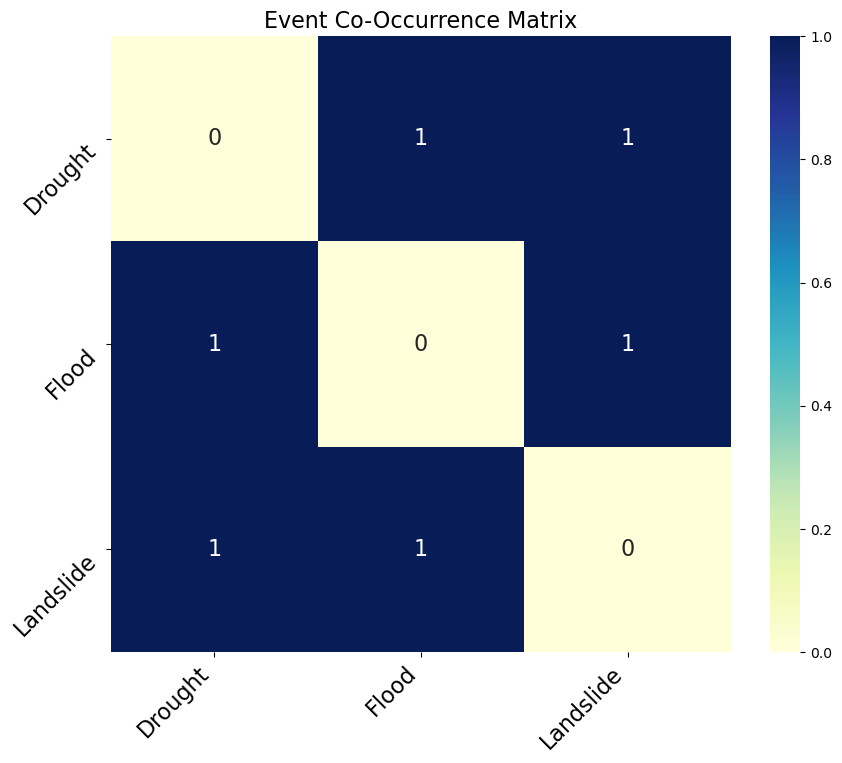

In [60]:
#Co-occurence matrix 
# Correlation matrix plot 
# Step 1: Identify unique events
# unique_events = set()
# for event_list in df_output['Hazard']:
#     unique_events.update(event_list)
unique_events = np.unique(df_output['Hazard'].tolist())
unique_events = sorted(unique_events)

# Step 2: Create the co-occurrence matrix
co_occurrence_matrix = pd.DataFrame(0, index=unique_events, columns=unique_events)

for appeal in appeal_codes : 
    report = df_output.loc[df_output.appealCode == appeal]
    event_list = report['Hazard']
    if len(event_list) > 1 : 
        for i in range(len(event_list)):
            for j in range(i, len(event_list)):
                if i != j:
                    co_occurrence_matrix.loc[event_list[i], event_list[j]] += 1
                    co_occurrence_matrix.loc[event_list[j], event_list[i]] += 1
                # else : 
                #     co_occurrence_matrix.loc[event_list[i], event_list[j]] += 1

# Step 3: Plot the matrix
fig=plt.figure(figsize=(10, 8))
sns.heatmap(co_occurrence_matrix, annot=True, cmap="YlGnBu", fmt="d", 
            annot_kws={"size": 16})  # Increase annotation font size
plt.title("Event Co-Occurrence Matrix", fontsize=16)  # Increase title font size
#plt.xlabel("Your X-axis Label", fontsize=14)  # Optional: add X-axis label
#plt.ylabel("Your Y-axis Label", fontsize=14)  # Optional: add Y-axis label
plt.xticks(fontsize=16, rotation=45, ha='right')  # Increase x-axis tick font size
plt.yticks(fontsize=16, rotation=45, va='top')  # Increase y-axis tick font size
plt.show()
fig.tight_layout()
#fig.savefig(fig_path+"co_occurence_matrix_compound_LLM.png", transparent=True)#, tight_layout=True)

In [63]:
#Map number of compound in each countries
unique_countries_haz = np.unique(df_output['Country']).tolist()
nb_compound_country = {country: 0 for country in unique_countries_haz}

#dict(unique_countries_haz)
for appeal in appeal_codes : 
    report = df_output.loc[df_output.appealCode == appeal]
    #Check if more than one hazard are identified
    if len(report)>1 : 
        unique_countires_rep = np.unique(df_output['Country'].tolist())
        for country in unique_countires_rep : 
            nb_compound_country[country]+=1

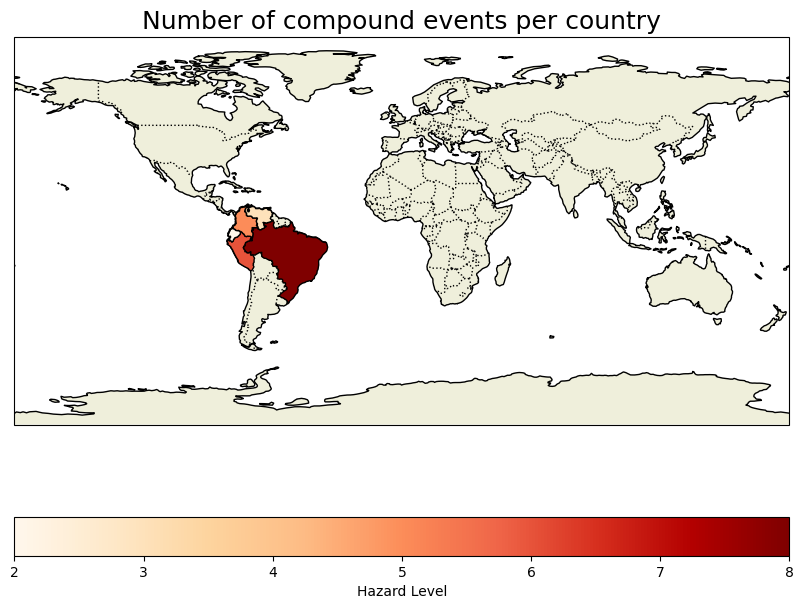

In [72]:
# Example dictionary with ISO3 country codes and hazard values
country_haz_dict = {
    'COL': 5,
    'VEN': 3,
    'BRA': 8,
    'ECU': 2,
    'PER': 6
}

# Initialize figure and axis with Cartopy projection
fig, ax = plt.subplots(1, 1, figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# Set up the colormap
cmap = plt.get_cmap('OrRd')  # You can change this colormap if needed
norm = mcolors.Normalize(vmin=min(country_haz_dict.values()), vmax=max(country_haz_dict.values()))

# Add features: land, coastlines, and borders
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')

# Load the Natural Earth shapefiles
shapefile = shpreader.natural_earth(resolution='110m', category='cultural', name='admin_0_countries')
reader = shpreader.Reader(shapefile)
countries = reader.records()

# Loop over countries in the shapefile and color them based on the hazard value
for country in countries:
    iso3 = country.attributes['ADM0_A3']
    
    # If the country's ISO3 code is in the hazard dict, color it
    if iso3 in country_haz_dict:
        hazard_value = country_haz_dict[iso3]
        color = cmap(norm(hazard_value))
        ax.add_geometries([country.geometry], ccrs.PlateCarree(), facecolor=color, edgecolor='black')

# Add a colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # Only needed for the colorbar to function properly
plt.colorbar(sm, ax=ax, orientation='horizontal', label='Hazard Level')

# Set a title
ax.set_title('Number of compound events per country', fontsize=18)

# Show the plot
plt.show()

In [81]:
df_output

,Hazard,Name,Country,Locations,Start_Date,End_Date,Hazard_Sentences,appealCode
0,Flood,NULL,KEN,Nairobi,March-April-May,NULL,Communities in Kenya are once again facing hea...,MDRDZ011
1,Landslide,NULL,KEN,NULL,NULL,NULL,There were also cases of landslides and mudsli...,MDRDZ011
2,Drought,NULL,KEN,NULL,four decades,NULL,The floods of 2023 floods and these 2024 flood...,MDRDZ011


In [83]:
hazard_counts = df_output.groupby(['Country', 'Hazard']).size().unstack(fill_value=0)

In [92]:
min(hazard_counts['Flood'].values)

1

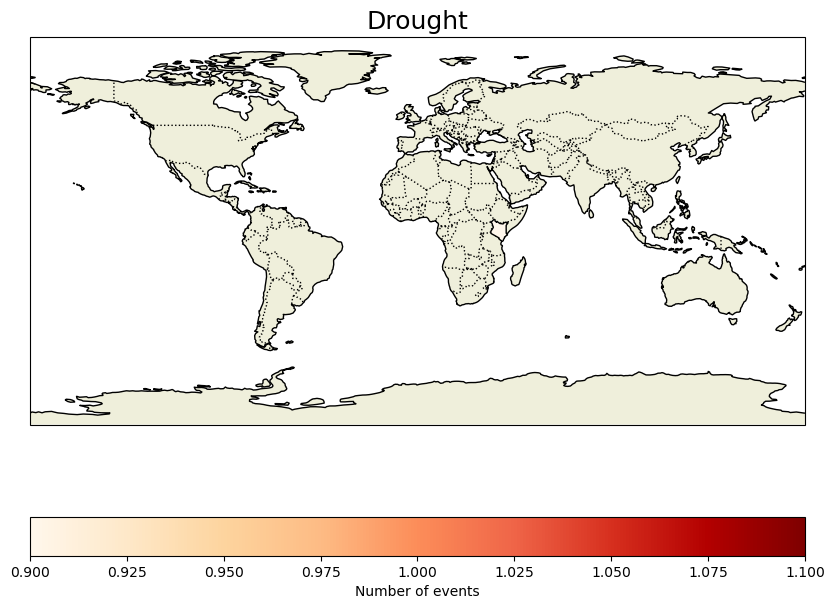

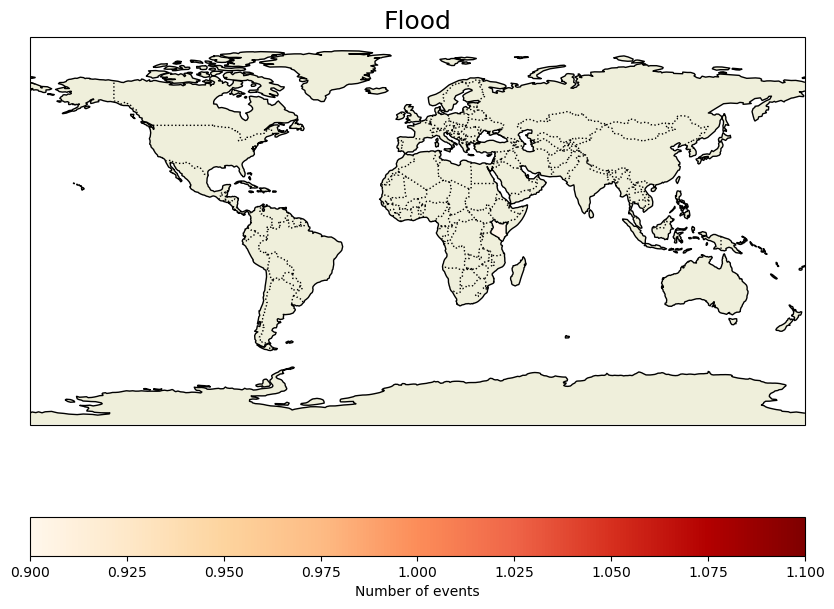

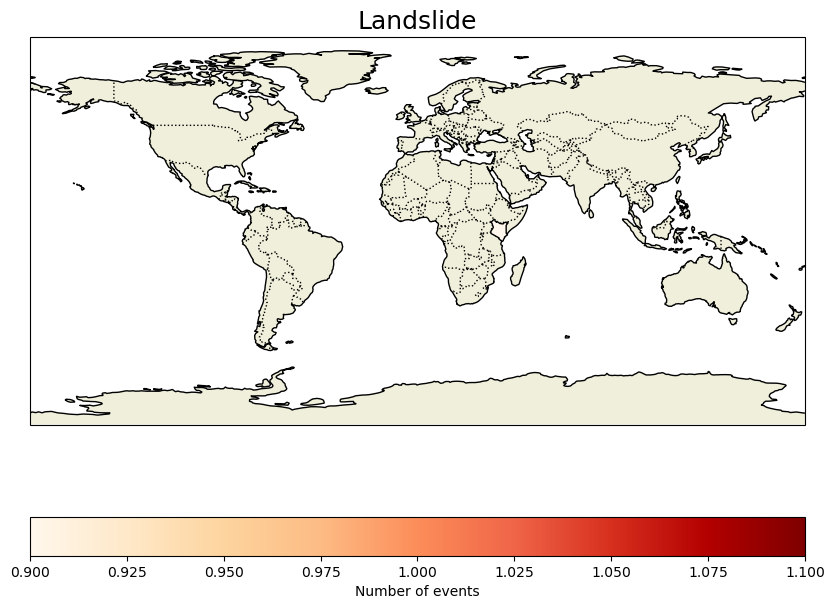

In [95]:
for haz in hazard_counts.columns.tolist() : 
    # Initialize figure and axis with Cartopy projection
    fig, ax = plt.subplots(1, 1, figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})
    
    # Set up the colormap
    cmap = plt.get_cmap('OrRd')  # You can change this colormap if needed
    norm = mcolors.Normalize(vmin=min(hazard_counts[haz].values), vmax=max(hazard_counts[haz].values))
    
    # Add features: land, coastlines, and borders
    ax.add_feature(cfeature.LAND)
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    
    # Load the Natural Earth shapefiles
    shapefile = shpreader.natural_earth(resolution='110m', category='cultural', name='admin_0_countries')
    reader = shpreader.Reader(shapefile)
    countries = reader.records()
    
    # Loop over countries in the shapefile and color them based on the hazard value
    for country in countries:
        iso3 = country.attributes['ADM0_A3']
        
        # If the country's ISO3 code is in the hazard dict, color it
        if iso3 in unique_countries_haz:
            hazard_value = hazard_counts.loc[iso3, haz]
            color = cmap(norm(hazard_value))
            ax.add_geometries([country.geometry], ccrs.PlateCarree(), facecolor=color, edgecolor='black')
    
    # Add a colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])  # Only needed for the colorbar to function properly
    plt.colorbar(sm, ax=ax, orientation='horizontal', label='Number of events')
    
    # Set a title
    ax.set_title(haz, fontsize=18)
    
    # Show the plot
    plt.show()

In [ ]:
#Total number of compounded hazard in each country 
for haz in

In [ ]:
#Add a column to say if the report contains compounded hazard


In [ ]:
hazard_patterns_hw = {
'Drought': r"drought.|dry spell.", 
'Flood': r"\b(flood|floods|flooding|inundation|inundations|glacial lake outburst)\b",
'Storm': r"storm.|superstorm.|tornado.|windstorm.|snowstorm.|snowfal.|blizzard.|derecho.|winterstorm.|hail.|extra tropical storm.|thunderstorm.",
'Tornado': r"tornado.*",
'Storm surge': r"storm surge.*",
'Heatwave': r"heat wave.|heatwave.|heat episode.|((heat|hot) spell).|heat stress.*|high temperature.*",
'Coldwave': r"cold wave.|coldwave.|severe winter conditions.|cold spell.",
'Mass movement': r"land slide.|landslide.|rockfall.|mudslide.|mass movement.*",
'Cyclone': r"cyclone.|tropical cyclone.|hurricane.|typhoon.",
'Tidal Wave': r"tidal wav.*",
'Wildfire': r"fire.|forestfire.|wildfire.|landfire.|bushfire.|forest fire.|wild fire.|land fire.|bush fire.*" }